# Potential Outcomes SMD — Model–Data Alignment

**Chapter 7 (RQ1).** Standardized Mean Difference (SMD) as a data-derived, model-independent baseline for feature relevance, scaled to **10 datasets** and tested against decision-tree (Gini) and MLP (SHAP) feature-importance rankings.

Runs top-to-bottom offline: Phase 1 loaders read cached frames from `./data/`, the SMD engine is deterministic, and Phase 2 fixes all random seeds. Outputs are written to `./<dataset>_plots/`, `./data/*_base_smd.csv`, `./data/alignment_summary.csv`, and `./alignment_plots/agreement_at_k.png`.

## Engine — EntropySplitter · StandardizedMeanDifferenceAnalyzer · PotentialOutcomesSMD

In [ ]:
from __future__ import annotations
"""
binned_smd.py
=============
Standardized Mean Difference analysis with a potential-outcomes framing.

The binary target defines two "worlds" (e.g. survived=0 / survived=1).
Every feature — raw, entropy-binned, or categorical level — becomes a
binary indicator whose SMD measures how unequally it is distributed across
those two worlds.

Classes
-------
EntropySplitter                      supervised binary/recursive splitter
StandardizedMeanDifferenceAnalyzer   original two-group SMD (unchanged)
PotentialOutcomesSMD                 main analyzer: base SMD ranking
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path


def _entropy(y: pd.Series) -> float:
    p = y.mean()
    if p in (0.0, 1.0):
        return 0.0
    return -p * np.log2(p) - (1 - p) * np.log2(1 - p)


def _information_gain(x: pd.Series, y: pd.Series, threshold: float) -> float:
    left_mask = x <= threshold
    n = len(y)
    n_left, n_right = left_mask.sum(), (~left_mask).sum()
    if n_left == 0 or n_right == 0:
        return 0.0
    return (
        _entropy(y)
        - (n_left / n) * _entropy(y[left_mask])
        - (n_right / n) * _entropy(y[~left_mask])
    )


def _best_split(x: pd.Series, y: pd.Series) -> tuple[float, float]:
    candidates = x.sort_values().unique()
    midpoints = (candidates[:-1] + candidates[1:]) / 2
    best_gain, best_thresh = -np.inf, np.nan
    for thresh in midpoints:
        gain = _information_gain(x, y, thresh)
        if gain > best_gain:
            best_gain, best_thresh = gain, thresh
    return best_thresh, best_gain


class EntropySplitter:
    """
    Recursively splits a continuous variable to maximise information gain
    w.r.t. a binary target, producing up to `max_bins` bins.
    """

    def __init__(self, max_bins: int = 2, min_samples_leaf: int = 20):
        if max_bins < 2:
            raise ValueError("max_bins must be at least 2")
        self.max_bins = max_bins
        self.min_samples_leaf = min_samples_leaf
        self.thresholds_: list[float] = []

    def fit(self, x: pd.Series, y: pd.Series) -> "EntropySplitter":
        self.thresholds_ = []
        regions = [(x.index, "root")]

        for _ in range(self.max_bins - 1):
            best_gain_global = -np.inf
            best_thresh_global = None

            for idx, _ in regions:
                x_r, y_r = x.loc[idx], y.loc[idx]
                if len(x_r) < 2 * self.min_samples_leaf:
                    continue
                thresh, gain = _best_split(x_r, y_r)
                if gain > best_gain_global:
                    left_n = (x_r <= thresh).sum()
                    right_n = (x_r > thresh).sum()
                    if left_n >= self.min_samples_leaf and right_n >= self.min_samples_leaf:
                        best_gain_global = gain
                        best_thresh_global = thresh

            if best_thresh_global is None or best_gain_global <= 0:
                break

            self.thresholds_.append(best_thresh_global)
            thresholds_sorted = sorted(self.thresholds_)
            regions = []
            edges = [-np.inf] + thresholds_sorted + [np.inf]
            for i in range(len(edges) - 1):
                mask = (x > edges[i]) & (x <= edges[i + 1])
                regions.append((x[mask].index, f"bin_{i}"))

        return self

    def transform(self, x: pd.Series) -> pd.Series:
        if not self.thresholds_:
            raise ValueError("Call fit() before transform()")
        thresholds_sorted = sorted(self.thresholds_)
        edges = [-np.inf] + thresholds_sorted + [np.inf]
        name = x.name or "x"

        def _label(i):
            lo, hi = edges[i], edges[i + 1]
            if lo == -np.inf:
                return f"{name} ≤ {hi:.4g}"
            if hi == np.inf:
                return f"{name} > {lo:.4g}"
            return f"{lo:.4g} < {name} ≤ {hi:.4g}"

        labels = [_label(i) for i in range(len(edges) - 1)]
        return pd.cut(x, bins=edges, labels=labels)

    def fit_transform(self, x: pd.Series, y: pd.Series) -> pd.Series:
        return self.fit(x, y).transform(x)

    @property
    def n_bins(self) -> int:
        return len(self.thresholds_) + 1



# StandardizedMeanDifferenceAnalyzer  (original)


class StandardizedMeanDifferenceAnalyzer:
    """Analyzes standardized mean differences between two groups in a dataset."""

    def __init__(self, df, group_col, features):
        self.df = df
        self.group_col = group_col
        self.features = features
        self.results = None

    def calculate(self):
        group_means = self.df.groupby(self.group_col)[self.features].mean().T
        groups = sorted(self.df[self.group_col].unique())
        if len(groups) != 2:
            raise ValueError(
                f"Group column must have exactly 2 unique values, found {len(groups)}"
            )

        group0, group1 = groups
        delta = group_means[group1] - group_means[group0]
        std0 = self.df[self.df[self.group_col] == group0][self.features].std()
        std1 = self.df[self.df[self.group_col] == group1][self.features].std()
        pooled_std = np.sqrt((std0 ** 2 + std1 ** 2) / 2)
        delta_std = abs(delta / pooled_std)

        self.results = pd.DataFrame({
            f'mean_{self.group_col}={group0}': group_means[group0],
            f'mean_{self.group_col}={group1}': group_means[group1],
            'delta': delta,
            'delta_std': delta_std,
        })
        self.results = self.results.reindex(
            self.results['delta_std'].abs().sort_values(ascending=False).index
        )
        return self.results

    def plot(self, figsize=(7, 4), color='skyblue', title=None, ax=None):
        if self.results is None:
            raise ValueError("Must call calculate() before plotting")

        plot_series = self.results['delta_std'].iloc[::-1]
        standalone = ax is None
        if standalone:
            _, ax = plt.subplots(figsize=figsize)

        plot_series.plot(kind='barh', color=color, edgecolor='black', ax=ax)
        ax.axvline(0, color='black', linewidth=1)
        groups = sorted(self.df[self.group_col].unique())
        group0, group1 = groups
        if title is None:
            title = f'SMD  ({self.group_col}={group1} vs {group0})'
        ax.set_title(title)
        ax.set_xlabel('Standardized Difference (SD units)')
        ax.set_ylabel('Feature')

        if standalone:
            plt.tight_layout()
            plt.show()

    def print_results(self, precision=3):
        if self.results is None:
            raise ValueError("Must call calculate() before printing results")
        print(self.results.round(precision))

    def run(self, plot=True, print_results=True, **plot_kwargs):
        self.calculate()
        if plot:
            self.plot(**plot_kwargs)
        if print_results:
            self.print_results()
        return self.results



# PotentialOutcomesSMD


class PotentialOutcomesSMD:
    """
    SMD analysis framed as a potential-outcomes problem.

    The binary target defines two worlds (e.g. survived=0 / survived=1).
    Every feature — raw continuous, entropy-binned indicator, or
    categorical level — becomes a row whose mean_group=0 / mean_group=1
    columns show the proportion of each world satisfying that condition.
    A large delta_std means the condition is unequally distributed across
    the two worlds, i.e. it is informative about which world a unit ended up in.

    Parameters
    ----------
    df : pd.DataFrame
    target_col : str
        Binary outcome column (e.g. 'survived').
    raw_features : list[str], optional
        Numeric columns included as-is (mean compared between groups).
    features_to_bin : list[str], optional
        Continuous columns entropy-split into binary indicators.
    categorical_features : list[str], optional
        Categorical/binary columns whose levels become indicators.
    max_bins : int
        Max bins per entropy-split variable (default 3 → up to two splits).
    min_samples_leaf : int
        Min samples per leaf for entropy splits.
    output_dir : str or Path, optional
        Directory where all plots are saved as PNG files.
        If None (default), plots are displayed interactively instead.

    Example
    -------
    >>> analyzer = PotentialOutcomesSMD(
    ...     df=titanic,
    ...     target_col='survived',
    ...     raw_features=['fare', 'age'],
    ...     features_to_bin=['fare', 'age'],
    ...     categorical_features=['sex', 'pclass'],
    ...     max_bins=2,
    ...     output_dir='./plots',
    ... )
    >>> results = analyzer.run()
    """

    def __init__(
        self,
        df: pd.DataFrame,
        target_col: str,
        raw_features: list[str] | None = None,
        features_to_bin: list[str] | None = None,
        categorical_features: list[str] | None = None,
        max_bins: int = 3,
        min_samples_leaf: int = 20,
        output_dir: str | Path | None = None,
    ):
        self.df = df.copy()
        self.target_col = target_col
        self.raw_features = list(raw_features or [])
        self.features_to_bin = list(features_to_bin or [])
        self.categorical_features = list(categorical_features or [])
        self.max_bins = max_bins
        self.min_samples_leaf = min_samples_leaf

        
        if output_dir is not None:
            self.output_dir = Path(output_dir)
            self.output_dir.mkdir(parents=True, exist_ok=True)
        else:
            self.output_dir = None

        self.splitters_: dict[str, EntropySplitter] = {}
        self._working_df: pd.DataFrame | None = None
        self._indicators: dict[str, list[str]] = {}

        self.base_results_: pd.DataFrame | None = None
        self.full_results_: pd.DataFrame | None = None

    

    def _save_or_show(self, fig: plt.Figure, filename: str) -> None:
        """Save fig to output_dir/filename.png, or show interactively if no dir set."""
        if self.output_dir is not None:
            path = self.output_dir / filename
            fig.savefig(path, bbox_inches='tight', dpi=150)
            plt.close(fig)
            print(f"  saved → {path}")
        else:
            plt.tight_layout()
            plt.show()

    # ── Step 1: build indicators ──────────────────────────────────────────────

    def _build_indicators(self):
        self._working_df = self.df.copy()
        self._indicators = {}

        for col in self.features_to_bin:
            clean = self._working_df[[col, self.target_col]].dropna()
            x, y = clean[col], clean[self.target_col]

            splitter = EntropySplitter(
                max_bins=self.max_bins,
                min_samples_leaf=self.min_samples_leaf,
            )
            splitter.fit(x, y)
            self.splitters_[col] = splitter

            if not splitter.thresholds_:
                print(f"[EntropySplitter] '{col}' → no informative split, skipped")
                continue

            thresholds_sorted = sorted(splitter.thresholds_)
            edges = [-np.inf] + thresholds_sorted + [np.inf]
            print(f"[EntropySplitter] '{col}' → {splitter.n_bins} bins  "
                  f"@ {[round(t, 4) for t in thresholds_sorted]}")

            self._indicators[col] = []
            for i in range(len(edges) - 1):
                lo, hi = edges[i], edges[i + 1]
                label = (
                    f"{col} ≤ {hi:.4g}" if lo == -np.inf else
                    f"{col} > {lo:.4g}" if hi == np.inf else
                    f"{lo:.4g} < {col} ≤ {hi:.4g}"
                )
                ind = ((self._working_df[col] > lo) &
                       (self._working_df[col] <= hi)).astype(float)
                ind[self._working_df[col].isna()] = np.nan
                self._working_df[label] = ind
                self._indicators[col].append(label)

        for col in self.categorical_features:
            levels = sorted(self._working_df[col].dropna().unique())
            self._indicators[col] = []
            for lvl in levels:
                label = f"{col}={lvl}"
                ind = (self._working_df[col] == lvl).astype(float)
                ind[self._working_df[col].isna()] = np.nan
                self._working_df[label] = ind
                self._indicators[col].append(label)
            print(f"[Categorical]    '{col}' → {len(levels)} indicators  "
                  f"({', '.join(str(l) for l in levels)})")

    # ── Step 2: base SMD ──────────────────────────────────────────────────────

    def _compute_base_smd(self):
        all_indicator_cols = [col for v in self._indicators for col in self._indicators[v]]
        all_features = self.raw_features + all_indicator_cols

        analyzer = StandardizedMeanDifferenceAnalyzer(
            df=self._working_df,
            group_col=self.target_col,
            features=all_features,
        )
        self.base_results_ = analyzer.calculate()

    # ── Step 4: merge ─────────────────────────────────────────────────────────

    def _merge_results(self):
        groups = sorted(self._working_df[self.target_col].dropna().unique())
        g0, g1 = groups
        m0, m1 = f'mean_{self.target_col}={g0}', f'mean_{self.target_col}={g1}'

        base = self.base_results_[[m0, m1, 'delta', 'delta_std']].copy()
        base['layer'] = 'base'
        self.full_results_ = base.sort_values('delta_std', ascending=False)

    # ── Plots ──────────────────────────────────────────────────────────────────

    def plot_base(self, figsize=(10, 6), title=None):
        if self.base_results_ is None:
            raise ValueError("Call run() first")

        groups = sorted(self._working_df[self.target_col].dropna().unique())
        g0, g1 = groups
        plot_series = self.base_results_['delta_std'].iloc[::-1]

        raw_set = set(self.raw_features)
        bin_set = {col for v in self.features_to_bin for col in self._indicators.get(v, [])}
        cat_set = {col for v in self.categorical_features for col in self._indicators.get(v, [])}

        colors = []
        for feat in plot_series.index:
            if feat in raw_set:
                colors.append('steelblue')
            elif feat in cat_set:
                colors.append('mediumseagreen')
            else:
                colors.append('coral')

        fig, ax = plt.subplots(figsize=figsize)
        plot_series.plot(kind='barh', color=colors, edgecolor='black', ax=ax)
        ax.axvline(0, color='black', linewidth=1)

        legend_items = []
        if self.raw_features:
            legend_items.append(mpatches.Patch(color='steelblue', label='raw feature'))
        if self.features_to_bin:
            legend_items.append(mpatches.Patch(color='coral', label='entropy-binned indicator'))
        if self.categorical_features:
            legend_items.append(mpatches.Patch(color='mediumseagreen', label='categorical indicator'))
        if legend_items:
            ax.legend(handles=legend_items, loc='lower right', fontsize=9)

        if title is None:
            title = (f'Base SMD  —  {self.target_col}={g1} vs {self.target_col}={g0}\n'
                     f'indicator rows = proportion of each world satisfying that condition')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Standardized Difference (SD units)')
        ax.set_ylabel('Feature / Condition')

        self._save_or_show(fig, 'smd_base.png')

    # ── Print ──────────────────────────────────────────────────────────────────

    def print_results(self, layer: str = 'full', precision: int = 3,
                      top_n: int | None = None):
        """layer: 'base' | 'full'"""
        mapping = {
            'base': self.base_results_,
            'full': self.full_results_,
        }
        df = mapping.get(layer)
        if df is None or (hasattr(df, 'empty') and df.empty):
            print(f"No results for layer='{layer}'")
            return
        groups = sorted(self._working_df[self.target_col].dropna().unique())
        g0, g1 = groups
        print(f"\n── SMD Results ({layer})  |  "
              f"{self.target_col}={g1} vs {self.target_col}={g0} ──")
        out = df.head(top_n) if top_n else df
        print(out.round(precision).to_string())

    # ── Main entry point ───────────────────────────────────────────────────────

    def run(
        self,
        plot_base: bool = True,
        print_results: bool = True,
    ) -> pd.DataFrame:
        """
        Pipeline:
          1. Build entropy-binned + categorical indicators
          2. Compute base SMD (raw features + indicators vs target)
          3. Rank the resulting conditions by |delta_std|

        Plots are saved to output_dir (if set) or shown interactively.
        Returns full_results_ DataFrame.
        """
        print("── Building indicators ──────────────────────────────────────")
        self._build_indicators()

        print("\n── Computing base SMD ───────────────────────────────────────")
        self._compute_base_smd()

        self._merge_results()

        if self.output_dir is not None:
            print(f"\n── Saving plots to {self.output_dir} ────────────────────")

        if plot_base:
            self.plot_base()

        if print_results:
            self.print_results(layer='base')

        return self.full_results_


## Phase 1 — Registry-driven scaling to 10 datasets

One `load_<name>()` per dataset (cached to `./data/<name>.csv`), the `PotentialOutcomesSMD` analyzer, and a single config-driven driver.

In [3]:
# ==================================================================
# Phase 1 — Registry-driven scaling to 10 datasets
# (this exact code block is embedded into the notebook)
# ==================================================================
import io, zipfile, urllib.request
from pathlib import Path
import pandas as pd, numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import fetch_openml, load_breast_cancer

DATA_DIR = Path('./data'); DATA_DIR.mkdir(exist_ok=True)

def _cached(name, build):
    """Build a processed dataframe once; cache to ./data/<name>.csv for
    reproducible, offline re-runs. Delete the CSV to force a rebuild."""
    p = DATA_DIR / f'{name}.csv'
    if p.exists():
        return pd.read_csv(p)
    df = build(); df.to_csv(p, index=False)
    return df

# ---- existing 4 (self-contained; reproduce prior preprocessing) --------------
def load_titanic():
    def _b():
        d = sns.load_dataset('titanic')
        d['sex']   = d['sex'].map({'male': 1, 'female': 0})
        d['class'] = d['class'].map({'Third': 3, 'Second': 2, 'First': 1})
        d['embarked'] = LabelEncoder().fit_transform(d['embarked'].astype(str))
        d['age'] = d['age'].fillna(d['age'].median())   # FIX: was sex.median() -> imputed 0/1
        return d
    return _cached('titanic', _b)

def load_diabetes():
    def _b():  # Pima, via OpenML (no local diabetes.csv needed)
        d = fetch_openml('diabetes', version=1, as_frame=True, parser='auto').frame.copy()
        d = d.rename(columns={'preg':'Pregnancies','plas':'Glucose','pres':'BloodPressure',
            'skin':'SkinThickness','insu':'Insulin','mass':'BMI',
            'pedi':'DiabetesPedigreeFunction','age':'Age'})
        d['Outcome'] = (d['class'] == 'tested_positive').astype(int)
        return d.drop(columns=['class'])
    return _cached('diabetes', _b)

def load_adult():
    def _b():
        r = fetch_openml(name='adult', version=2, as_frame=True, parser='auto').frame.copy()
        r = r.dropna().reset_index(drop=True)
        r['income'] = (r['class'].str.strip().str.replace('.', '', regex=False) == '>50K').astype(int)
        r = r.drop(columns=['class', 'fnlwgt'])
        r = r.rename(columns={'education-num':'education_num','capital-gain':'capital_gain',
            'capital-loss':'capital_loss','hours-per-week':'hours_per_week',
            'marital-status':'marital_status','native-country':'native_country'})
        r['married'] = (r['marital_status'] == 'Married-civ-spouse').astype(int)
        r = r.drop(columns=['marital_status'])
        r['relationship_grp'] = r['relationship'].map({'Husband':'spouse','Wife':'spouse',
            'Not-in-family':'independent','Unmarried':'independent',
            'Own-child':'dependent','Other-relative':'dependent'})
        r = r.drop(columns=['relationship'])
        high = {'Exec-managerial','Prof-specialty','Protective-serv','Tech-support'}
        low  = {'Other-service','Handlers-cleaners','Farming-fishing','Priv-house-serv',
                'Machine-op-inspct','Armed-Forces'}
        r['occupation_grp'] = r['occupation'].apply(
            lambda x: 'high' if x in high else ('low' if x in low else 'mid'))
        r = r.drop(columns=['occupation'])
        r['workclass_grp'] = r['workclass'].map({'Federal-gov':'government','Local-gov':'government',
            'State-gov':'government','Self-emp-inc':'self_employed','Self-emp-not-inc':'self_employed',
            'Private':'private','Without-pay':'private'})
        r = r.drop(columns=['workclass'])
        r['race_grp'] = r['race'].map({'White':'white','Black':'black',
            'Asian-Pac-Islander':'other_race','Amer-Indian-Eskimo':'other_race','Other':'other_race'})
        r = r.drop(columns=['race'])
        for c in ['age','education_num','capital_gain','capital_loss','hours_per_week']:
            r[c] = pd.to_numeric(r[c], errors='coerce')
        return r
    d = _cached('adult', _b)
    if 'native_us' not in d.columns and 'native_country' in d.columns:
        d['native_us'] = (d['native_country'] == 'United-States').astype(int)
    return d

def load_compas():
    def _b():
        url = ("https://raw.githubusercontent.com/propublica/compas-analysis/"
               "master/compas-scores-two-years.csv")
        r = pd.read_csv(url)
        r = r[(r['days_b_screening_arrest'] <= 30) & (r['days_b_screening_arrest'] >= -30) &
              (r['is_recid'] != -1) & (r['c_charge_degree'] != 'O') &
              (r['score_text'] != 'N/A')].copy()
        r['race_black']      = (r['race'] == 'African-American').astype(int)
        r['juv_any']         = ((r['juv_fel_count'] + r['juv_misd_count'] + r['juv_other_count']) > 0).astype(int)
        r['sex']             = (r['sex'] == 'Male').astype(int)
        r['c_charge_degree'] = (r['c_charge_degree'] == 'F').astype(int)
        cols = ['age','sex','race_black','priors_count','c_charge_degree','juv_any','two_year_recid']
        return r[cols].dropna().reset_index(drop=True)
    return _cached('compas', _b)

# ---- new 6 -------------------------------------------------------------------
def load_breast_cancer_df():
    return _cached('breast_cancer', lambda: load_breast_cancer(as_frame=True).frame.copy())

def load_german():
    def _b():
        d = fetch_openml('credit-g', version=1, as_frame=True, parser='auto').frame.copy()
        d['target'] = (d['class'] == 'bad').astype(int)   # positive = bad credit
        return d.drop(columns=['class'])
    return _cached('german', _b)

_BANK_RENAME = {'V1':'age','V2':'job','V3':'marital','V4':'education','V5':'default',
    'V6':'balance','V7':'housing','V8':'loan','V9':'contact','V10':'day','V11':'month',
    'V12':'duration','V13':'campaign','V14':'pdays','V15':'previous','V16':'poutcome'}
def load_bank():
    def _b():
        d = fetch_openml('bank-marketing', version=1, as_frame=True, parser='auto').frame.copy()
        d = d.rename(columns=_BANK_RENAME)
        d['target'] = (d['Class'].astype(int) == 2).astype(int)   # 2 = subscribed
        return d.drop(columns=['Class', 'duration'])              # duration = leakage
    return _cached('bank', _b)

_ASEE_FEATURES = ['Gender', 'Early College HS?', 'HS Rank', 'GPA at Graduation',
    'Credits Transferred', 'Cal 1 Final Grade (MATH 1411)',
    'Cal 2 Final Grade (MATH 1312)', 'Statics Final Grade (MECH 1321)',
    'Chemistry Final Grade (CHEM 1305)']
def load_asee():
    def _b():  # UTEP engineering-retention study (ASEE 2026); 3-class Outcome
        d = pd.read_excel('asee_26_data_cleaned.xlsx')
        out = d[_ASEE_FEATURES].copy()
        out['degree_completion'] = (d['Outcome'] == 1).astype(int)  # 1 = completed; 0/2 = not
        out['HS Rank'] = out['HS Rank'].fillna(out['HS Rank'].median())
        return out
    return _cached('asee', _b)

def load_student():
    def _b():
        url = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"
        raw = urllib.request.urlopen(url, timeout=60).read()
        z = zipfile.ZipFile(io.BytesIO(raw))
        inner = zipfile.ZipFile(io.BytesIO(z.read('student.zip')))
        d = pd.read_csv(io.BytesIO(inner.read('student-por.csv')), sep=';')
        d['target'] = (d['G3'] >= 10).astype(int)          # pass
        return d.drop(columns=['G1', 'G2', 'G3'])          # period grades = leakage
    return _cached('student', _b)

_TAIWAN_RENAME = {'x1':'LIMIT_BAL','x2':'SEX','x3':'EDUCATION','x4':'MARRIAGE','x5':'AGE',
    'x6':'PAY_1','x7':'PAY_2','x8':'PAY_3','x9':'PAY_4','x10':'PAY_5','x11':'PAY_6',
    'x12':'BILL_AMT1','x13':'BILL_AMT2','x14':'BILL_AMT3','x15':'BILL_AMT4','x16':'BILL_AMT5',
    'x17':'BILL_AMT6','x18':'PAY_AMT1','x19':'PAY_AMT2','x20':'PAY_AMT3','x21':'PAY_AMT4',
    'x22':'PAY_AMT5','x23':'PAY_AMT6'}
def load_taiwan():
    def _b():
        d = fetch_openml('default-of-credit-card-clients', version=1, as_frame=True, parser='auto').frame.copy()
        d = d.rename(columns=_TAIWAN_RENAME)
        d['target'] = d['y'].astype(int)
        return d.drop(columns=['y'])
    return _cached('taiwan', _b)


In [4]:
# ---- registry ---------------------------------------------------------------
_BC_FEATS = [c for c in load_breast_cancer(as_frame=True).frame.columns if c != 'target']

DATASETS = {
 'titanic':       dict(loader=load_titanic, target='survived', raw=['sibsp','parch'],
    to_bin=['fare','age'], cat=['sex','pclass','embarked'], max_bins=3),
 'diabetes':      dict(loader=load_diabetes, target='Outcome',
    to_bin=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age'],
    cat=[], max_bins=2),
 'adult':         dict(loader=load_adult, target='income',
    to_bin=['age','education_num','capital_gain','capital_loss','hours_per_week'],
    cat=['sex','married','workclass_grp','occupation_grp','relationship_grp','race_grp','native_us'],
    max_bins=2),
 'compas':        dict(loader=load_compas, target='two_year_recid',
    to_bin=['age','priors_count'], cat=['sex','race_black','c_charge_degree','juv_any'],
    max_bins=3),
 'breast_cancer': dict(loader=load_breast_cancer_df, target='target',
    to_bin=_BC_FEATS, cat=[], max_bins=2),
 'german':        dict(loader=load_german, target='target',
    to_bin=['duration','credit_amount','installment_commitment','residence_since','age','existing_credits','num_dependents'],
    cat=['checking_status','credit_history','purpose','savings_status','employment','personal_status',
         'other_parties','property_magnitude','other_payment_plans','housing','job','own_telephone','foreign_worker'],
    max_bins=2),
 'bank':          dict(loader=load_bank, target='target',
    to_bin=['age','balance','day','campaign','pdays','previous'],
    cat=['job','marital','education','default','housing','loan','contact','month','poutcome'],
    max_bins=2),
 'asee':          dict(loader=load_asee, target='degree_completion',
    to_bin=['HS Rank','GPA at Graduation','Credits Transferred',
            'Cal 1 Final Grade (MATH 1411)','Cal 2 Final Grade (MATH 1312)',
            'Statics Final Grade (MECH 1321)','Chemistry Final Grade (CHEM 1305)'],
    cat=['Gender','Early College HS?'], max_bins=2),
 'student':       dict(loader=load_student, target='target',
    to_bin=['age','absences','failures','studytime','goout','Dalc','Walc','health','Medu','Fedu','traveltime','famrel','freetime'],
    cat=['school','sex','address','famsize','Pstatus','Mjob','Fjob','reason','guardian','schoolsup',
         'famsup','paid','activities','nursery','higher','internet','romantic'],
    max_bins=2),
 'taiwan':        dict(loader=load_taiwan, target='target',
    to_bin=['LIMIT_BAL','AGE','PAY_1','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
            'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
            'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'],
    cat=['SEX','EDUCATION','MARRIAGE'], max_bins=2),
}


In [5]:
# ---- driver: run the SMD pipeline over the registry ----
# Set RUN to a subset (e.g. ['titanic','breast_cancer']) for quick iteration.
# NOTE: 'taiwan' (~30k rows, many continuous cols) is the slow one (~3-4 min);
# results are cached under ./data/ and plots under ./<name>_plots/.
RUN = list(DATASETS)

smd_results = {}          # name -> ranked base SMD results
smd_base    = {}
smd_analyzers = {}          # name -> univariate base SMD (used by Phase 2 alignment)

for name in RUN:
    cfg = DATASETS[name]
    print(f"\n{'#'*70}\n# {name.upper()}\n{'#'*70}")
    df = cfg['loader']()
    print(f"n={len(df)}  target='{cfg['target']}'  balance={dict(df[cfg['target']].value_counts())}")
    analyzer = PotentialOutcomesSMD(
        df=df, target_col=cfg['target'],
        raw_features=cfg.get('raw', []),
        features_to_bin=cfg['to_bin'], categorical_features=cfg['cat'],
        max_bins=cfg['max_bins'],
        output_dir=f'./{name}_plots')
    smd_results[name] = analyzer.run(print_results=False)
    smd_base[name] = analyzer.base_results_
    smd_analyzers[name] = analyzer
    analyzer.base_results_.to_csv(DATA_DIR / f'{name}_base_smd.csv')

print(f"\nDone: {len(smd_results)}/10 datasets. Rankings in `smd_results` / `smd_base`.")



######################################################################
# TITANIC
######################################################################
n=891  target='survived'  balance={0: 549, 1: 342}
── Building indicators ──────────────────────────────────────
[EntropySplitter] 'fare' → 4 bins  @ [7.1334, 10.4812, 74.375]
[EntropySplitter] 'age' → 3 bins  @ [2.5, 6.5]
[Categorical]    'sex' → 2 indicators  (0, 1)
[Categorical]    'pclass' → 3 indicators  (1, 2, 3)
[Categorical]    'embarked' → 4 indicators  (0, 1, 2, 3)

── Computing base SMD ───────────────────────────────────────

── Computing interaction SMD ────────────────────────────────
   51 interaction terms computed (min_subgroup_size=30)

── Saving plots to titanic_plots ────────────────────
  saved → titanic_plots/smd_base.png
  saved → titanic_plots/smd_interactions.png
  saved → titanic_plots/smd_heatmap.png

######################################################################
# DIABETES
###########################

## Phase 2 — Model–data alignment (SMD vs DT vs SHAP)

**H1.** SMD reliably recovers a model's most important (top 1–3) features even when whole-ranking agreement (Spearman's ρ) is weak. We rank all three methods over the **same original-feature index set** (indicator-level SMD aggregated back to source features) and report full-list ρ against top-weighted metrics (RBO, weighted τ, Overlap@k, top-1/top-3 hits) with a permutation test for top-3 overlap. Three model rankings are compared: **decision tree** (Gini importance), **logistic regression** (|standardized coefficient|), and **MLP** (mean |SHAP|).

In [6]:
# ── Phase 2 helpers: rank similarity + SMD source-level scores ────────────────
import numpy as np, pandas as pd
from scipy.stats import spearmanr, weightedtau
import rbo as _rbo   # reference RBO implementation (pip install rbo)

SEED, RBO_P, PERM_N, MAX_ROWS = 0, 0.9, 10_000, 15_000

def rbo_ext(S, T, p=RBO_P):
    """Extrapolated Rank-Biased Overlap (Webber et al. 2010), computed with the
    reference `rbo` package rather than reimplemented."""
    return _rbo.RankingSimilarity(list(S), list(T)).rbo_ext(p=p)

def ranking(s):        return list(s.sort_values(ascending=False, kind="stable").index)
def overlap_at_k(a, b, k): return len(set(a[:k]) & set(b[:k])) / k

def smd_source_scores(an):
    """Aggregate indicator-level |SMD| back to the ORIGINAL feature (max per source)."""
    base = an.base_results_["delta_std"]; sc = {}
    for s in an.raw_features: sc[s] = float(abs(base.get(s, 0.0)))
    for s, inds in an._indicators.items():
        vals = [abs(base.get(i, 0.0)) for i in inds]
        sc[s] = float(max(vals)) if vals else 0.0
    return pd.Series(sc)


In [7]:
# ── Phase 2: model rankings (DT Gini, LR |coef|, MLP mean|SHAP|) — same feature set ─
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import shap

def build_Xy(df, cfg):
    """Design matrix over the source features SMD uses: numeric as-is,
    categoricals one-hot. colmap maps each design column back to its source."""
    y = df[cfg["target"]].astype(int).values
    num = list(cfg.get("raw", []) + cfg["to_bin"]); cat = cfg["cat"]
    Xnum = df[num].apply(pd.to_numeric, errors="coerce"); Xnum = Xnum.fillna(Xnum.median())
    blocks, colmap = [Xnum], {c: c for c in num}
    for c in cat:
        d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
        blocks.append(d)
        for dc in d.columns: colmap[dc] = c
    return pd.concat(blocks, axis=1), y, num + cat, colmap

def agg_importance(imp, colmap, source):
    out = {s: 0.0 for s in source}
    for col, v in imp.items(): out[colmap[col]] += float(v)
    return pd.Series(out)

def dt_scores(Xtr, ytr, Xte, yte, colmap, source):
    clf = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=SEED).fit(Xtr, ytr)
    return agg_importance(pd.Series(clf.feature_importances_, index=Xtr.columns), colmap, source), clf.score(Xte, yte)

def lr_scores(Xtr, ytr, Xte, yte, colmap, source):
    sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    lr = LogisticRegression(max_iter=1000, random_state=SEED).fit(Xtr_s, ytr)   # rank by |std. coef|
    return agg_importance(pd.Series(np.abs(lr.coef_[0]), index=Xtr.columns), colmap, source), lr.score(Xte_s, yte)

def shap_scores(Xtr, ytr, Xte, yte, colmap, source, rng):
    sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)
    mlp = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=400,
                        random_state=SEED, early_stopping=True).fit(Xtr_s, ytr)
    bg = shap.kmeans(Xtr_s, min(15, len(Xtr_s)))
    idx = rng.choice(len(Xte_s), min(80, len(Xte_s)), replace=False)
    expl = shap.KernelExplainer(lambda z: mlp.predict_proba(z)[:, 1], bg)
    sv = np.asarray(expl.shap_values(Xte_s[idx], nsamples="auto", silent=True))
    return agg_importance(pd.Series(np.abs(sv).mean(axis=0), index=Xtr.columns), colmap, source), mlp.score(Xte_s, yte)

def pair_metrics(smd_s, mdl_s, source, rng):
    # a feature with no informative SMD split / zero model importance = 0, not NaN
    smd_s = smd_s.reindex(source).fillna(0.0)
    mdl_s = mdl_s.reindex(source).fillna(0.0)
    r_smd, r_mdl = ranking(smd_s), ranking(mdl_s); p = len(source)
    sp = spearmanr(smd_s.values, mdl_s.values).correlation
    wt = weightedtau(smd_s.values, mdl_s.values).correlation
    rbo = rbo_ext(r_smd, r_mdl); smd1 = r_smd[0]
    top1 = int(smd1 == r_mdl[0]); top3 = int(smd1 in set(r_mdl[:3]))
    ov3 = overlap_at_k(r_smd, r_mdl, 3)
    smd3 = set(r_smd[:3]); arr = np.array(r_mdl, dtype=object); ge = 0
    for _ in range(PERM_N):
        if len(smd3 & set(rng.permutation(arr)[:3])) / 3 >= ov3 - 1e-12: ge += 1
    perm_p = (ge + 1) / (PERM_N + 1)
    curve  = [overlap_at_k(r_smd, r_mdl, k) for k in range(1, p + 1)]
    chance = [k / p for k in range(1, p + 1)]
    return dict(p=p, spearman=sp, rbo=rbo, wtau=wt, top1_hit=top1, top3_hit=top3,
                overlap3=ov3, perm_p=perm_p), curve, chance


/Users/henrysalgado/opt/anaconda3/envs/data_science_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# ── Phase 2 run: three rankings per dataset, metrics, summary table ───────────
# H1: SMD recovers the model's most-important (top 1-3) features even when
#     whole-ranking agreement (Spearman) is weak.
MODELS = ("DT", "LR", "SHAP")
rows, curves, rankings = [], {}, {}
for name in DATASETS:
    cfg = DATASETS[name]; df = cfg["loader"]()
    if len(df) > MAX_ROWS:                                   # cap huge sets for the models
        df = df.groupby(cfg["target"], group_keys=False).apply(
            lambda d: d.sample(int(round(MAX_ROWS * len(d) / len(df))), random_state=SEED)
        ).reset_index(drop=True)
    smd_s = smd_source_scores(smd_analyzers[name])
    X, y, source, colmap = build_Xy(df, cfg)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
    dt_s, dt_acc = dt_scores(Xtr, ytr, Xte, yte, colmap, source)
    lr_s, lr_acc = lr_scores(Xtr, ytr, Xte, yte, colmap, source)
    sh_s, sh_acc = shap_scores(Xtr, ytr, Xte, yte, colmap, source, np.random.RandomState(SEED))
    rankings[name] = {"SMD": ranking(smd_s.reindex(source).fillna(0.0))}
    for mdl, s, acc in (("DT", dt_s, dt_acc), ("LR", lr_s, lr_acc), ("SHAP", sh_s, sh_acc)):
        m, curve, chance = pair_metrics(smd_s, s, source, np.random.RandomState(SEED))
        rows.append(dict(dataset=name, model=mdl, acc=round(acc, 3), **m))
        curves[(name, mdl)] = (curve, chance)
        rankings[name][mdl] = ranking(s.reindex(source).fillna(0.0))
    print(f"{name:14s} p={len(source):2d}  DTacc={dt_acc:.3f}  LRacc={lr_acc:.3f}  MLPacc={sh_acc:.3f}  SMD#1={ranking(smd_s)[0]}")

alignment = pd.DataFrame(rows)
alignment.to_csv(DATA_DIR / "alignment_summary.csv", index=False)
print("\nsaved -> data/alignment_summary.csv")
alignment.round(3)


/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)


titanic        p= 7  DTacc=0.799  LRacc=0.802  MLPacc=0.806  SMD#1=sex
diabetes       p= 8  DTacc=0.723  LRacc=0.775  MLPacc=0.771  SMD#1=Glucose


/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)


adult          p=12  DTacc=0.846  LRacc=0.841  MLPacc=0.842  SMD#1=relationship_grp


/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/

...

/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/

heart          p=13  DTacc=0.704  LRacc=0.790  MLPacc=0.790  SMD#1=thal
student        p=30  DTacc=0.841  LRacc=0.841  MLPacc=0.779  SMD#1=failures


/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)
/var/folders/gk/cvk0vx853198tmxc1bd6_x240000gn/T/ipykernel_1090/4161519901.py:17: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  d = pd.get_dummies(df[c].astype("object"), prefix=c, prefix_sep="=").astype(float)


taiwan         p=23  DTacc=0.815  LRacc=0.815  MLPacc=0.824  SMD#1=PAY_1

saved -> data/alignment_summary.csv


,dataset,model,acc,p,spearman,rbo,wtau,top1_hit,top3_hit,overlap3,perm_p
0,titanic,DT,0.799,7,0.893,0.969,0.894,1,1,1.000,0.029
1,titanic,LR,0.802,7,0.571,0.914,0.653,1,1,0.667,0.377
2,titanic,SHAP,0.806,7,0.857,0.950,0.837,1,1,0.667,0.367
3,diabetes,DT,0.723,8,0.619,0.883,0.689,1,1,1.000,0.017
4,diabetes,LR,0.775,8,0.738,0.924,0.758,1,1,0.667,0.291
5,diabetes,SHAP,0.771,8,0.929,0.977,0.928,1,1,1.000,0.017
6,adult,DT,0.846,12,0.580,0.815,0.572,1,1,0.333,0.613
7,adult,LR,0.841,12,0.776,0.737,0.457,0,0,0.333,0.609
8,adult,SHAP,0.842,12,0.755,0.740,0.514,0,0,0.333,0.629
9,compas,DT,0.681,6,0.143,0.870,0.329,1,1,0.333,0.948


saved -> alignment_plots/agreement_at_k.png


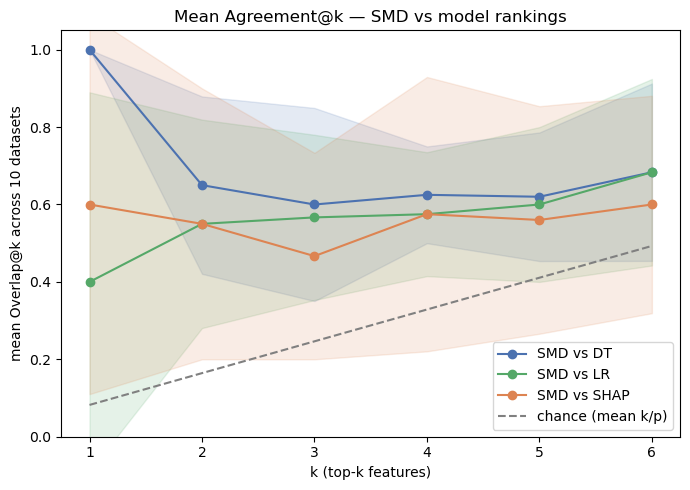

In [9]:
# ── Headline figure: mean Agreement@k across the 10 datasets vs chance ────────
import matplotlib.pyplot as plt
K = min(len(v[0]) for v in curves.values())      # = min p (all datasets contribute)
fig, ax = plt.subplots(figsize=(7, 5))
for mdl, col in (("DT", "#4C72B0"), ("LR", "#55A868"), ("SHAP", "#DD8452")):
    M = np.array([curves[(n, mdl)][0][:K] for n in DATASETS])
    ax.plot(range(1, K + 1), M.mean(0), "-o", color=col, label=f"SMD vs {mdl}")
    ax.fill_between(range(1, K + 1), M.mean(0) - M.std(0), M.mean(0) + M.std(0), color=col, alpha=.15)
Ch = np.array([curves[(n, "DT")][1][:K] for n in DATASETS]).mean(0)
ax.plot(range(1, K + 1), Ch, "--", color="grey", label="chance (mean k/p)")
ax.set_xlabel("k (top-k features)"); ax.set_ylabel("mean Overlap@k across 10 datasets")
ax.set_title("Mean Agreement@k — SMD vs model rankings")
ax.set_xticks(range(1, K + 1)); ax.set_ylim(0, 1.05); ax.legend()
from pathlib import Path
Path("./alignment_plots").mkdir(exist_ok=True)
fig.tight_layout(); fig.savefig("./alignment_plots/agreement_at_k.png", dpi=150)
print("saved -> alignment_plots/agreement_at_k.png")
plt.show()


### Top-3 features per method

In [10]:
# ── Top-3 features per method (domain sanity check) ───────────────────────────
top_rows = []
for name in DATASETS:
    r = rankings[name]
    top_rows.append(dict(dataset=name,
        SMD =" > ".join(map(str, r["SMD"][:3])),
        DT  =" > ".join(map(str, r["DT"][:3])),
        LR  =" > ".join(map(str, r["LR"][:3])),
        SHAP=" > ".join(map(str, r["SHAP"][:3]))))
top_features = pd.DataFrame(top_rows)
top_features.to_csv(DATA_DIR / "top_features.csv", index=False)
print("saved -> data/top_features.csv")
top_features


saved -> data/top_features.csv


,dataset,SMD,DT,LR,SHAP
0,titanic,sex > pclass > fare,sex > pclass > fare,sex > pclass > age,sex > pclass > embarked
1,diabetes,Glucose > BMI > Age,Glucose > Age > BMI,Glucose > BMI > Pregnancies,Glucose > BMI > Age
2,adult,relationship_grp > married > age,relationship_grp > education_num > capital_gain,capital_gain > married > education_num,married > education_num > occupation_grp
3,compas,priors_count > juv_any > race_black,priors_count > age > sex,priors_count > age > sex,priors_count > age > sex
4,breast_cancer,worst perimeter > mean concave points > worst ...,worst perimeter > worst concave points > mean ...,radius error > worst texture > mean concave po...,worst radius > worst area > worst smoothness
5,german,checking_status > credit_history > duration,checking_status > duration > savings_status,purpose > credit_history > checking_status,checking_status > employment > purpose
6,bank,poutcome > contact > pdays,poutcome > month > age,month > contact > poutcome,poutcome > contact > month
7,heart,thal > chest > number_of_major_vessels,thal > oldpeak > chest,number_of_major_vessels > chest > thal,number_of_major_vessels > thal > exercise_indu...
8,student,failures > school > higher,failures > school > romantic,Fjob > school > failures,activities > internet > Mjob
9,taiwan,PAY_1 > PAY_2 > PAY_3,PAY_1 > PAY_2 > PAY_AMT3,PAY_1 > BILL_AMT1 > EDUCATION,PAY_1 > BILL_AMT2 > SEX


In [11]:
# ── H1 read-out: low full-list rho but high top-k agreement, per method ───────
for mdl in MODELS:
    sub = alignment[alignment.model == mdl]
    print(f"{mdl:4s}: top1 {int(sub.top1_hit.sum())}/10  top3 {int(sub.top3_hit.sum())}/10  "
          f"mean_rho {sub.spearman.mean():.2f}  mean_RBO {sub.rbo.mean():.2f}  "
          f"perm_p<0.05: {int((sub.perm_p<0.05).sum())}/10")
print(f"\nOverall: top1 {int(alignment.top1_hit.sum())}/{len(alignment)}  "
      f"top3 {int(alignment.top3_hit.sum())}/{len(alignment)}  "
      f"mean_rho {alignment.spearman.mean():.2f}  mean_RBO {alignment.rbo.mean():.2f}")
alignment.pivot_table(index="dataset", columns="model",
    values=["spearman", "rbo", "top3_hit", "perm_p"]).round(3)


DT  : top1 10/10  top3 10/10  mean_rho 0.54  mean_RBO 0.79  perm_p<0.05: 5/10
LR  : top1 4/10  top3 8/10  mean_rho 0.45  mean_RBO 0.71  perm_p<0.05: 3/10
SHAP: top1 6/10  top3 7/10  mean_rho 0.45  mean_RBO 0.70  perm_p<0.05: 1/10

Overall: top1 20/30  top3 25/30  mean_rho 0.48  mean_RBO 0.73


perm_p                  rbo               spearman         \
model             DT     LR   SHAP     DT     LR   SHAP       DT     LR   
dataset                                                                   
adult          0.613  0.609  0.629  0.815  0.737  0.740    0.580  0.776   
bank           0.514  0.083  0.084  0.730  0.640  0.786    0.581  0.325   
breast_cancer  0.283  0.278  0.278  0.601  0.544  0.435    0.312  0.607   
compas         0.948  0.948  0.953  0.870  0.870  0.870    0.143  0.257   
diabetes       0.017  0.291  0.017  0.883  0.924  0.977    0.619  0.738   
german         0.046  0.047  0.403  0.752  0.672  0.636    0.560  0.634   
heart          0.112  0.003  0.111  0.827  0.719  0.742    0.764  0.429   
student        0.020  0.018  1.000  0.647  0.522  0.277    0.318  0.403   
taiwan         0.036  0.359  0.358  0.782  0.511  0.545    0.624 -0.216   
titanic        0.029  0.377  0.367  0.969  0.914  0.950    0.893  0.571   

                     top3_hit          
model           SHAP       DT LR SHAP  
dataset                                
adult          0.755        1  0    0  
bank           0.239        1  1    1  
breast_cancer  0.373        1  0    0  
compas         0.314        1  1    1  
diabetes       0.929        1  1    1  
german         0.506        1  1    1  
heart          0.604        1  1    1  
student       -0.165        1  1    0  
taiwan         0.089        1  1    1  
titanic        0.857        1  1    1